In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from scipy.stats import gaussian_kde
from optiland.materials import Material

In [2]:
m = Material('DNA')

In [3]:
df = m._load_dataframe()
df = df[df['group'] == 'glass']

In [4]:
n = []
v = []
for k, row in tqdm(df.iterrows(), total=len(df)):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = Material(row['filename_no_ext'])
            n.append(m.n(0.58756))
            v.append(m.abbe())
    except ValueError:
        pass

n = np.array(n)
v = np.array(v)

100%|██████████| 1777/1777 [00:09<00:00, 183.57it/s]


In [5]:
# filter out outliers & invalid values
id_valid = (n > 1.4) & (n < 2.0) & (v > 0.0) & (v < 100.0) & np.isfinite(n) & np.isfinite(v)
n = n[id_valid]
v = v[id_valid]

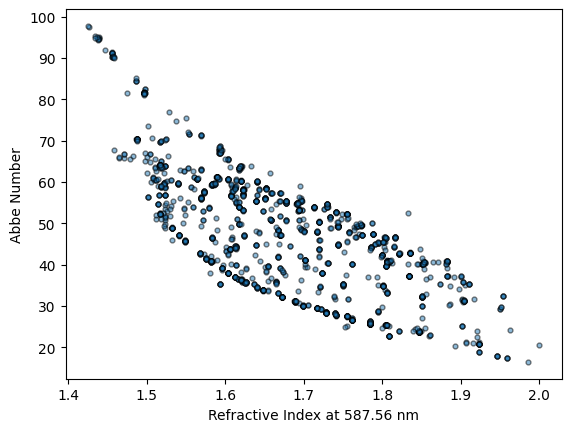

In [6]:
plt.scatter(n, v, s=12, edgecolor='k', alpha=0.5)
plt.xlabel('Refractive Index at 587.56 nm')
plt.ylabel('Abbe Number')
plt.show()

In [7]:
data = np.vstack([n, v])

# filter out non-finite values
data = data[:, np.all(np.isfinite(data), axis=0)]

kde = gaussian_kde(data)

In [8]:
n_samples = 10000  # Number of samples you want to retrieve
samples = kde.resample(n_samples)

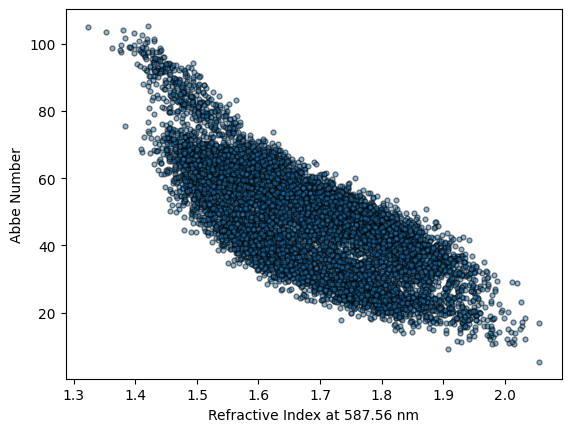

In [9]:
n_new, v_new = samples

plt.scatter(n_new, v_new, s=12, edgecolor='k', alpha=0.5)
plt.xlabel('Refractive Index at 587.56 nm')
plt.ylabel('Abbe Number')
plt.show()

In [10]:
with open('kde_model.pkl', 'wb') as f:
    pickle.dump(kde, f)